Here we will test the algorithm of Douglas-Peucker without pymeos (MovingPandas library), then with pymeos (MobilityPandas library).

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
# from tqdm.notebook import tqdm
# import contextily as cx
# from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file
import zipfile

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
from pyproj import Transformer

import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()

In [39]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'large': 10000000}
chosen_size = 'small'

# AIS data
## MovingPandas (without PyMEOS)

In [40]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )

    global nb_points
    nb_points = df.shape[0]

# extraction()

In [41]:
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(lon, lat) for lon, lat in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])
    gdf = gdf.drop(columns=['lat', 'lon'])

    global trajectories_without
    trajectories_without = mpd.TrajectoryCollection(gdf, traj_id_col='mmsi', t='t')

# construction_without()

In [42]:
def simplify_without():
    global simplified_without
    simplified_without = mpd.DouglasPeuckerGeneralizer(trajectories_without).generalize(tolerance=1)

# simplify_without()

## MobilityPandas (with PyMEOS)

### from_instants method

In [43]:
def construction_from_instants():

    """
    The trajectories calculated here will not be used in the following of this study, since they are exactly the same as the ones calculated with from_arrays method.
    """

    df2 = df.copy()
    df2['geometry'] = [Point(x, y) for x, y in zip(df2['x'], df2['y'])]
    df2["point"] = df2.apply(
        lambda row: TGeomPointInst(
            point=row["geometry"],
            timestamp=row["t"],
            srid=25832,
        ),
        axis=1,
    )

    trajectories_with = (df2.groupby("mmsi")
        .aggregate({"point": lambda traj: TGeomPointSeq.from_instants(traj, upper_inc=True)})
        .rename({"point": "trajectory"}, axis=1)
    )

# construction_from_instants()

### from_arrays method

In [44]:
def construction_from_arrays():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

# construction_from_arrays()

In [45]:
# check that the from_arrays and from_instants trajectories are identical

# n = 109
# m = [traj.id for traj in trajectories_without][n]

# trajectories_without.trajectories[n].plot(color='black', label='movingpandas', linewidth=8)
# trajectories_with3.trajectory[m].plot(color='red', label='mobilitypandas with from_arrays', linewidth=5)
# trajectories_with2.trajectory[m].plot(color='blue', label='mobilitypandas with from_instants', linewidth=2)
# plt.title("Example : trajectory {0}".format(n))
# plt.legend()
# plt.show()

# a=[trajectories_with2.trajectory[i].num_instants() for i in trajectories_with2.index] #from_instants
# b=[trajectories_with3.trajectory[i].num_instants() for i in trajectories_with3.index] #from_arrays 
# print(sum(a), sum(b))

In [46]:
def simplify_with():
    global simplified_with
    simplified_with = trajectories_with.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=1, synchronized=False)
    )

# simplify_with()

In [ ]:
def simplify_sync():
    global simplified_sync
    simplified_sync = trajectories_with.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=1, synchronized=True)
    )

# simplify_sync()

In [48]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=5):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)
    # results[f.__name__] = (mean_t, 0)  # if you don't want to calculate memory usage


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_without)
benchmark_cpu_time(construction_from_instants)
benchmark_cpu_time(construction_from_arrays)
benchmark_cpu_time(simplify_without)
benchmark_cpu_time(simplify_with)
benchmark_cpu_time(simplify_sync)


Function extraction:
CPU time over 5 runs: 3.809743 sec ± 0.053524 sec
Memory usage : 82.12 MiB

Function construction_without:
CPU time over 5 runs: 3.575924 sec ± 0.435239 sec
Memory usage : 1.93 MiB

Function construction_from_instants:
CPU time over 5 runs: 1.125166 sec ± 0.207581 sec
Memory usage : 1.25 MiB

Function construction_from_arrays:
CPU time over 5 runs: 0.954263 sec ± 0.012912 sec
Memory usage : 0.62 MiB

Function simplify_without:
CPU time over 5 runs: 4.011011 sec ± 0.233840 sec
Memory usage : 0.00 MiB

Function simplify_with:
CPU time over 5 runs: 0.014055 sec ± 0.001239 sec
Memory usage : 0.00 MiB

Function simplify_sync:
CPU time over 5 runs: 0.019170 sec ± 0.000227 sec
Memory usage : 0.12 MiB



In [49]:
# extraction()
# construction_without()
# construction_from_instants()
# construction_from_arrays()
# simplify_without()
# simplify_with()
# simplify_sync()

# Performance measures

## Reduction

In [50]:
kept_points_without = 0
for traj in simplified_without.trajectories :
    kept_points_without += traj.size()

kept_points_with = 0
for traj in simplified_with :
    kept_points_with += traj.num_instants()

kept_points_sync = 0
for traj in simplified_sync :
    kept_points_sync += traj.num_instants()

print("Proportion of points kept : (without pymeos, with pymeos, with sync)")
print(np.round(kept_points_without/nb_points, 2), np.round(kept_points_with/nb_points, 2), np.round(kept_points_sync/nb_points, 2))

Proportion of points kept : (without pymeos, with pymeos, with sync)
0.37 0.3 0.22


## Preservation

### Hausdorff distance 
It doesn't take the time into account...

In [52]:
hausdorff_without = [trajectories_without.trajectories[i].hausdorff_distance(simplified_without.trajectories[i])
               for i in range(len(trajectories_without.trajectories))]

hausdorff_with = [trajectories_with.trajectory[trajectories_with.index[i]].hausdorff_distance(simplified_with.values[i])
               for i in range(len(trajectories_with.trajectory))]

hausdorff_sync = [trajectories_with.trajectory[trajectories_with.index[i]].hausdorff_distance(simplified_sync.values[i])
               for i in range(len(trajectories_with.trajectory))]

print("\naverage Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync) (meters):")
print(round(np.max(hausdorff_without), 2), round(np.max(hausdorff_with), 2), round(np.max(hausdorff_sync), 2))


average Hausdorff distance with the original trajectory (without pymeos, with pymeos, with sync) (meters):
1.06 1865.21 1872.19


### Spatial-temporal distortion
(area)

In [65]:
def calc_distortion_without():
    distortion_for_each_traj = []

    trajs_original = list(trajectories_without.trajectories)
    trajs_simplified = list(simplified_without.trajectories)

    for ti, ts in zip(trajs_original, trajs_simplified):
        timestamps = ti.df.index

        delta_t = np.diff(timestamps).astype('timedelta64[s]').astype(float)

        # extracting the positions at a same time for the two trajectories to compare 
        # left rectangles
        p1lefts, p2lefts = [ti.interpolate_position_at(timestamps[0])], [ts.get_position_at(timestamps[0])] # offset of one
        p1rights, p2rights = [], []

        for t in timestamps[1:-1]:

                p1lefts.append(ti.interpolate_position_at(t))
                p2lefts.append(ts.get_position_at(t))

                p1rights.append(ti.interpolate_position_at(t))
                p2rights.append(ts.get_position_at(t))

        p1rights.append(ti.interpolate_position_at(timestamps[-1]))
        p2rights.append(ts.get_position_at(timestamps[-1]))

        # distances between the two trajectories
        dlefts = np.array([p1.distance(p2) for p1, p2 in zip(p1lefts, p2lefts)])
        drights = np.array([p1.distance(p2) for p1, p2 in zip(p1rights, p2rights)])

        # time * trapeze area, ie integration (vectorized)
        total_area = 0.5 * (dlefts + drights) * delta_t  # [m * s]
        distortion_for_each_traj.append(total_area.sum() / 3600)  # [m * h]

    return distortion_for_each_traj


distortion_without = calc_distortion_without()

distortion_with = np.array([trajectories_with.trajectory.values[i].distance(simplified_with.values[i]).integral()
        for i in range(len(trajectories_with.trajectory.values))])/(3600*10**6)

# TODO : note that even this calculation is much faster with PyMEOS.


In [66]:
print("maximum distortion without pymeos (h*m): ", max(distortion_without))
print("average distortion without pymeos (h*m): ", np.mean(distortion_without))

print("maximum distortion with pymeos (h*m): ", max(distortion_with))
print("average distortion with pymeos (h*m): ", np.mean(distortion_with))

maximum distortion without pymeos (h*m):  10.828342524964771
average distortion without pymeos (h*m):  0.051133918095800084
maximum distortion with pymeos (h*m):  13.385450391592075
average distortion with pymeos (h*m):  0.03995638195747963


### Total length of the trajectories

In [ ]:
# TODO : table de correpondance m - n (=i ici)

gap_without, gap_with, gap_with_sync = [], [], []
for i in range(len(trajectories_without.trajectories)):
      m = [traj.id for traj in trajectories_without][i] # car ceci n'est pas optimisé
      lo = round(trajectories_without.trajectories[i].get_length(), 2)
      lwithout = round(simplified_without.trajectories[i].get_length(), 2)
      lwith2 = round(simplified_with[m].length(), 2)
      lsync = round(simplified_sync[m].length(), 2)

      gap_without.append(abs(lo-lwithout))
      gap_with.append(abs(lo-lwith2))
      gap_with_sync.append(abs(lo-lsync))

print(f"Max gap without pymeos (m) = {round(max(gap_without), 2)}, with pymeos = {round(max(gap_with), 2)}, with sync = {round(max(gap_with_sync), 2)}")
print(f"Average gap without pymeos (m) = {round(np.mean(gap_without), 2)}, with pymeos = {round(np.mean(gap_with), 2)}, with sync = {round(np.mean(gap_with_sync), 2)}\n")


Max gap without pymeos = 40.72, with pymeos = 40.72, with sync = 64.14
Average gap without pymeos = 0.8, with pymeos = 0.83, with sync = 2.83

Max gap time delta without pymeos = 0:00:00, with pymeos = 0:00:00, with sync = 0:00:00
Average gap time delta without pymeos = 0:00:00, with pymeos = 0:00:00, with sync = 0:00:00



## Let me see

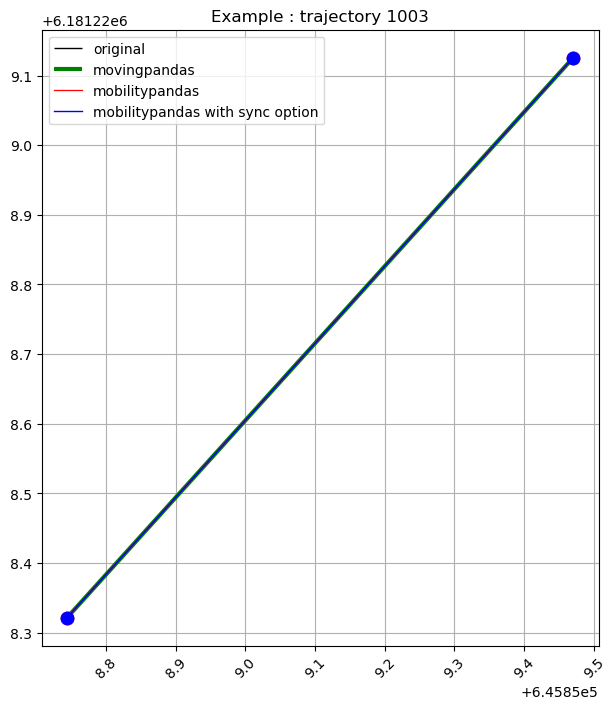

In [ ]:
# Plot one trajectory

# n=109 is a good one
n=109
m = [traj.id for traj in trajectories_without][n] # the corresponding MMSI

fig, ax = plt.subplots(figsize=(12, 8))
trajectories_without.trajectories[n].plot(color='black', label='original', linewidth=1, ax=ax)
simplified_without.trajectories[n].plot(color='green', label='movingpandas', ax=ax, linewidth=3)
simplified_with[m].plot(color='red', label='mobilitypandas', linewidth=0.9)
simplified_sync[m].plot(color='blue', label='mobilitypandas with sync option', linewidth=1)

plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()


# print(simplified_without.trajectories[n].size(), simplified_with2.values[n].num_instants())
# print(trajectories_without.trajectories[n].get_start_location(), trajectories_with2.trajectory[m].start_value())
# print(simplified_without.trajectories[n].get_start_location(), simplified_with2.values[n].start_value())
# print()
# print(trajectories_without.trajectories[n], '\n\n', trajectories_with2.values[n])

def from_mmsi(collection, mmsi):
    if isinstance(collection, mpd.TrajectoryCollection):
        return next(
            traj for traj in collection.trajectories
            if 'mmsi' in traj.df.columns and traj.df['mmsi'].iloc[0] == mmsi
        )
    elif isinstance(collection, pd.Series):
        return next(
            traj for traj in collection.values
            if traj.index == mmsi
        )



## Visualisation

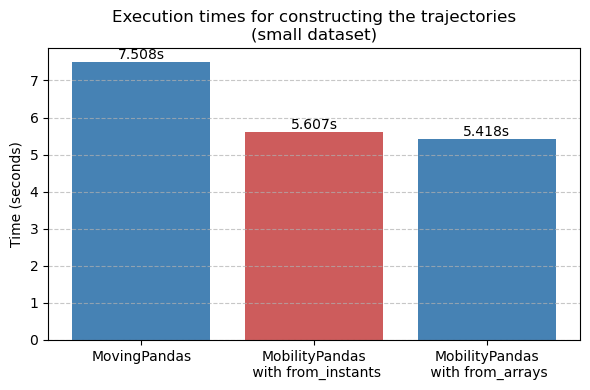

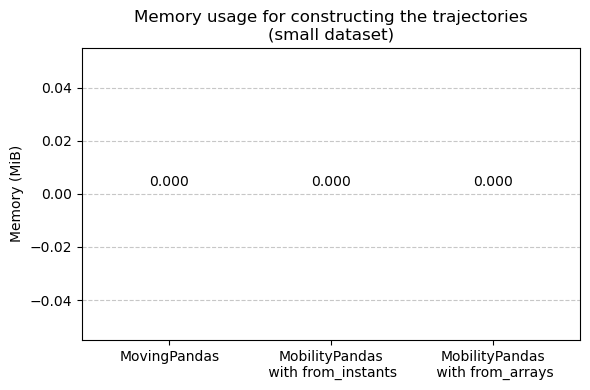

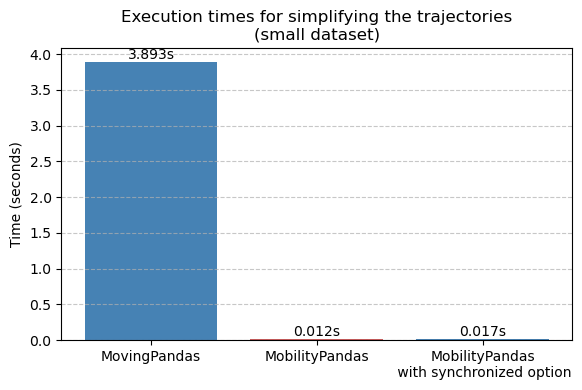

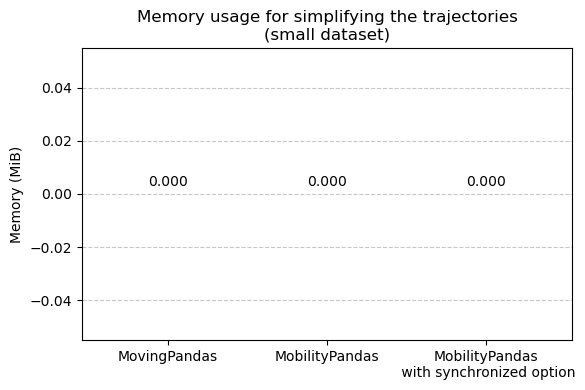

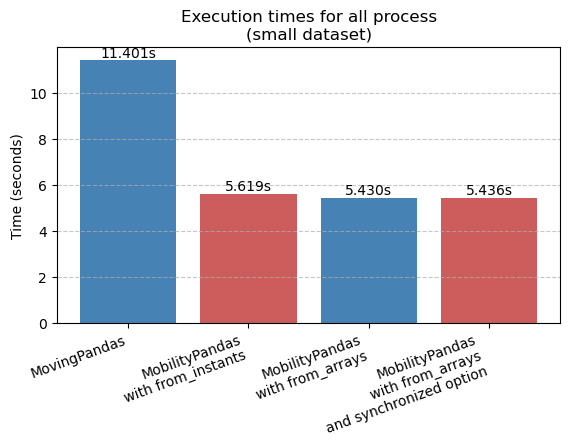

In [28]:

# Construction
timesCo = [results['extraction'][0] + results['construction_without'][0], results['extraction'][0]+ results['construction_from_instants'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0]]
memCo = [results['construction_without'][1], results['construction_from_instants'][1], results['construction_from_arrays'][1]]
libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays']


plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Calculation
timesCa = [results['simplify_without'][0], results['simplify_with'][0], results['simplify_sync'][0]]
memCa = [results['simplify_without'][1], results['simplify_with'][1], results['simplify_sync'][1]]
libsCa = ['MovingPandas', 'MobilityPandas', 'MobilityPandas\n with synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Total
times = [results['extraction'][0] + results['construction_without'][0] + results['simplify_without'][0], 
         results['extraction'][0]+ results['construction_from_instants'][0] + results['simplify_with'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_with'][0],
         results['extraction'][0]+ results['construction_from_arrays'][0] + results['simplify_sync'][0]]

libs = ['MovingPandas', 'MobilityPandas\n with from_instants', 'MobilityPandas\n with from_arrays', 
        'MobilityPandas\n with from_arrays\nand synchronized option']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(rotation=20, ha='right')
plt.show()
